Registro del Dataset, Descripción e Interrogantes de Investigación
Nombre del dataset: Breast Cancer Wisconsin (Diagnostic)

Fuente: scikit-learn / UCI Machine Learning Repository

Liga de acceso: scikit-learn Breast Cancer Dataset

Contexto: El conjunto de datos contiene mediciones numéricas calculadas a partir de imágenes digitalizadas de aspirados con aguja fina (FNA) de masas mamarias.

Unidad de registro: Cada registro representa una muestra de tejido tumoral observada mediante biopsia por aspiración.

Variable objetivo (y): Categórica binaria (0 = Maligno, 1 = Benigno).

In [ ]:
from sklearn.datasets import load_breast_cancer

# Cargar los datos
cancer = load_breast_cancer()

# Acceder a las variables (X) y a las etiquetas (y)
X = cancer.data
y = cancer.target

print("Variables shape:", X.shape)

Variables shape: (569, 30)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer

# Cargar dataset
data = load_breast_cancer(as_frame=True)
df = data.frame

# Revisión inicial
print("--- Número de registros y variables ---")
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")

print("\n--- Tipos de datos y nulos ---")
print(df.info())

print("\n--- Valores faltantes por columna ---")
print(df.isnull().sum().sum())

print("\n--- Posibles registros duplicados ---")
print(f"Duplicados: {df.duplicated().sum()}")

print("\n--- Distribución de la variable objetivo ---")
print(df['target'].value_counts(normalize=False))
print(df['target'].value_counts(normalize=True).round(4) * 100)

--- Número de registros y variables ---
Filas: 569, Columnas: 31

--- Tipos de datos y nulos ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separar características (X) y objetivo (y)
X = df.drop(columns=['target'])
y = df['target']

# Guardar copia de etiquetas reales
y_true = y.copy()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Conjunto de Entrenamiento: {X_train.shape[0]} muestras")
print(f"Conjunto de Prueba: {X_test.shape[0]} muestras")

Conjunto de Entrenamiento: 455 muestras
Conjunto de Prueba: 114 muestras


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
# Se elimina 'ClassificationReportDisplay' y se agrega 'ConfusionMatrixDisplay'
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Definir Pipelines para evitar Data Leakage
pipeline_svm_lineal = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='linear', random_state=42))
])

pipeline_svm_rbf = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', random_state=42))
])

# Entrenar modelos
pipeline_svm_lineal.fit(X_train, y_train)
pipeline_svm_rbf.fit(X_train, y_train)

# Predicciones
y_pred_lineal = pipeline_svm_lineal.predict(X_test)
y_pred_rbf = pipeline_svm_rbf.predict(X_test)

# Métricas
def obtener_metricas(y_real, y_pred):
    return [
        accuracy_score(y_real, y_pred),
        precision_score(y_real, y_pred),
        recall_score(y_real, y_pred),
        f1_score(y_real, y_pred)
    ]

m_lineal = obtener_metricas(y_test, y_pred_lineal)
m_rbf = obtener_metricas(y_test, y_pred_rbf)

# Tabla de Resultados
tabla_svm = pd.DataFrame([m_lineal, m_rbf],
                         columns=['Accuracy', 'Precision', 'Recall', 'F1-score'],
                         index=['Modelo 1 (Lineal)', 'Modelo 2 (RBF)'])
print(tabla_svm.round(4))

                   Accuracy  Precision  Recall  F1-score
Modelo 1 (Lineal)    0.9737     0.9859  0.9722    0.9790
Modelo 2 (RBF)       0.9825     0.9861  0.9861    0.9861


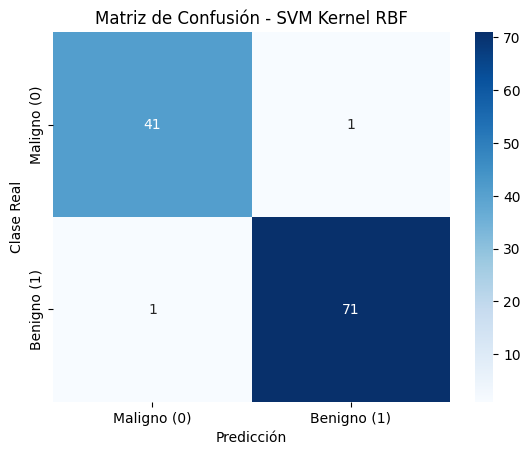

In [ ]:
cm = confusion_matrix(y_test, y_pred_rbf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Maligno (0)', 'Benigno (1)'],
            yticklabels=['Maligno (0)', 'Benigno (1)'])
plt.xlabel('Predicción')
plt.ylabel('Clase Real')
plt.title('Matriz de Confusión - SVM Kernel RBF')
plt.show()

In [ ]:
# Comparación del hiperparámetro C en SVM RBF
for c_val in [0.1, 1.0, 10.0]:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(kernel='rbf', C=c_val, random_state=42))
    ])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    print(f"C = {c_val:<4} | Accuracy: {accuracy_score(y_test, preds):.4f} | F1: {f1_score(y_test, preds):.4f}")

C = 0.1  | Accuracy: 0.9474 | F1: 0.9589
C = 1.0  | Accuracy: 0.9825 | F1: 0.9861
C = 10.0 | Accuracy: 0.9737 | F1: 0.9790


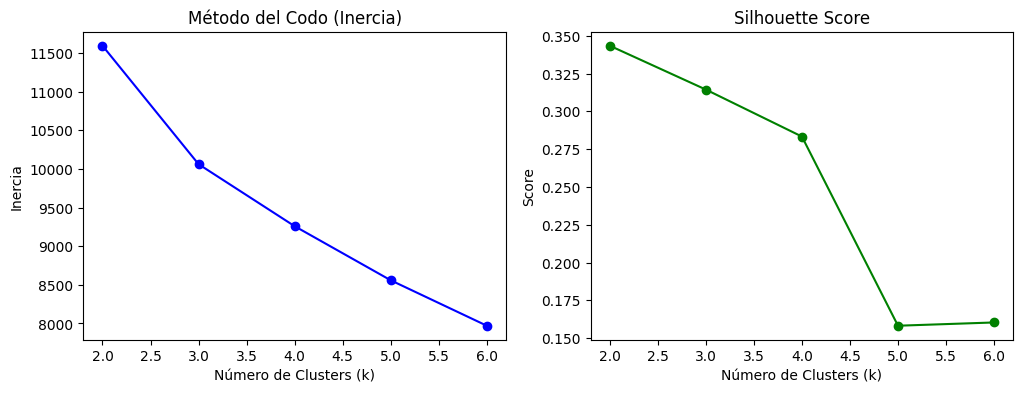

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Escalar las variables completas (sin la variable objetivo)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Evaluación de K entre 2 y 6
inercia = []
silhouette_scores = []
k_range = range(2, 7)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inercia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Gráfica de Codo y Silhouette Score
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(k_range, inercia, marker='o', color='b')
ax[0].set_title('Método del Codo (Inercia)')
ax[0].set_xlabel('Número de Clusters (k)')
ax[0].set_ylabel('Inercia')

ax[1].plot(k_range, silhouette_scores, marker='o', color='g')
ax[1].set_title('Silhouette Score')
ax[1].set_xlabel('Número de Clusters (k)')
ax[1].set_ylabel('Score')

plt.show()

In [ ]:
# Aplicar K-Means con k=2
kmeans_final = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_scaled)

# Asignar clusters al DataFrame original
df_clusters = df.copy()
df_clusters['cluster'] = cluster_labels

# Resumen de tamaño y características principales
features_interes = ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean concavity']
resumen_clusters = df_clusters.groupby('cluster')[features_interes].mean()
resumen_clusters['tamaño'] = df_clusters['cluster'].value_counts()

print(resumen_clusters.T.round(2))

cluster              0       1
mean radius      12.43   17.41
mean texture     18.26   21.28
mean perimeter   79.82  115.45
mean area       486.77  979.86
mean concavity    0.04    0.18
tamaño          375.00  194.00


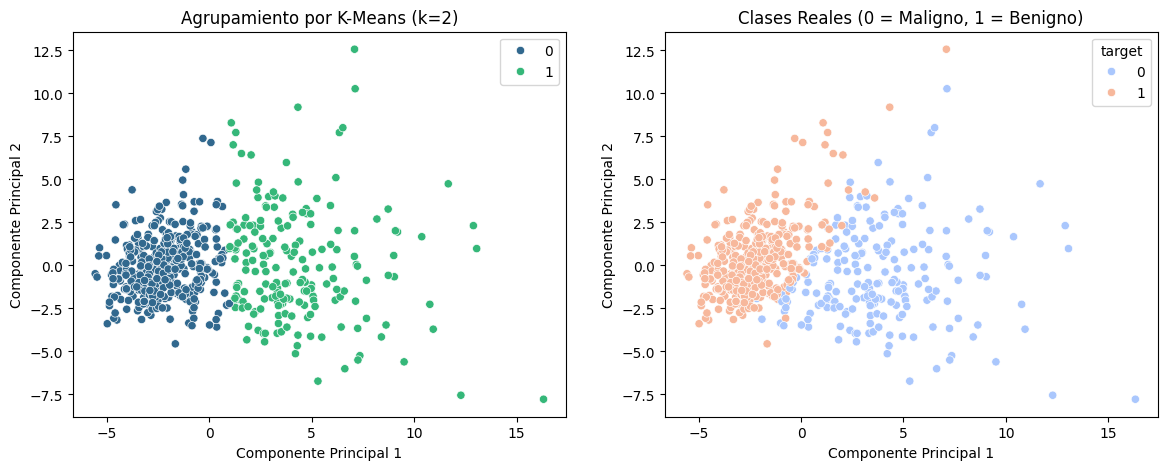

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica Clusters K-Means
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=cluster_labels, palette='viridis', ax=ax[0])
ax[0].set_title('Agrupamiento por K-Means (k=2)')
ax[0].set_xlabel('Componente Principal 1')
ax[0].set_ylabel('Componente Principal 2')

# Gráfica Clases Reales
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='coolwarm', ax=ax[1])
ax[1].set_title('Clases Reales (0 = Maligno, 1 = Benigno)')
ax[1].set_xlabel('Componente Principal 1')
ax[1].set_ylabel('Componente Principal 2')

plt.show()

In [ ]:
# Mapeo de clusters contra clases reales
crosstab = pd.crosstab(df_clusters['cluster'], y, rownames=['Cluster'], colnames=['Clase Real (0=Maligno, 1=Benigno)'])
print(crosstab)

Clase Real (0=Maligno, 1=Benigno)    0    1
Cluster                                    
0                                   36  339
1                                  176   18
